In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression


In [2]:
data = pd.read_csv("D:\Codink\Project\Machine Learning - Learn\dengue_detect\dengue_detection\Dengue_diseases_dataset_modified (1).csv")
data.head()

,age,gender,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width,dengue_label
0,43,Male,12.6,2200.0,1,1,62000.0,11.0,1
1,45,Male,13.2,3000.0,0,1,17000.0,17.0,1
2,50,Female,11.0,3300.0,1,1,19000.0,16.3,1
3,57,Female,11.9,3500.0,1,0,29000.0,14.0,1
4,51,Female,13.0,3100.0,0,1,30000.0,14.5,1


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 989 entries, 0 to 988
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          989 non-null    int64  
 1   gender                       989 non-null    str    
 2   hemoglobin_g_dl              989 non-null    float64
 3   wbc_count                    965 non-null    float64
 4   differential_count           989 non-null    int64  
 5   rbc_count                    989 non-null    int64  
 6   platelet_count               973 non-null    float64
 7   platelet_distribution_width  970 non-null    float64
 8   dengue_label                 989 non-null    int64  
dtypes: float64(4), int64(4), str(1)
memory usage: 69.7 KB


In [4]:
data.describe()

,age,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width,dengue_label
count,989.000000,989.000000,965.000000,989.000000,989.000000,973.000000,970.000000,989.000000
mean,42.199191,13.712942,4338.031088,0.939333,0.938322,114702.241521,22.848866,0.651163
std,20.941111,1.484111,2344.529755,0.238840,0.240692,89421.766107,14.692872,0.476843
min,3.000000,11.000000,2000.000000,0.000000,0.000000,10000.000000,1.000000,0.000000
25%,27.000000,12.600000,2600.000000,1.000000,1.000000,46000.000000,14.000000,0.000000
50%,40.000000,13.700000,3200.000000,1.000000,1.000000,93000.000000,17.800000,1.000000
75%,55.000000,15.000000,6200.000000,1.000000,1.000000,162500.000000,28.200000,1.000000
max,120.000000,25.000000,10900.000000,1.000000,1.000000,500000.000000,215.000000,1.000000


In [5]:
data['rbc_count'].value_counts()

rbc_count
1    928
0     61
Name: count, dtype: int64

In [6]:
## Drop Duplicates Data
data.drop_duplicates(inplace=True)

#Checking missing Data
(data.isnull().sum() / len(data)) * 100

age                            0.000000
gender                         0.000000
hemoglobin_g_dl                0.000000
wbc_count                      2.426694
differential_count             0.000000
rbc_count                      0.000000
platelet_count                 1.617796
platelet_distribution_width    1.921132
dengue_label                   0.000000
dtype: float64

C:\Users\user\AppData\Local\Temp\ipykernel_23060\3267262998.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns


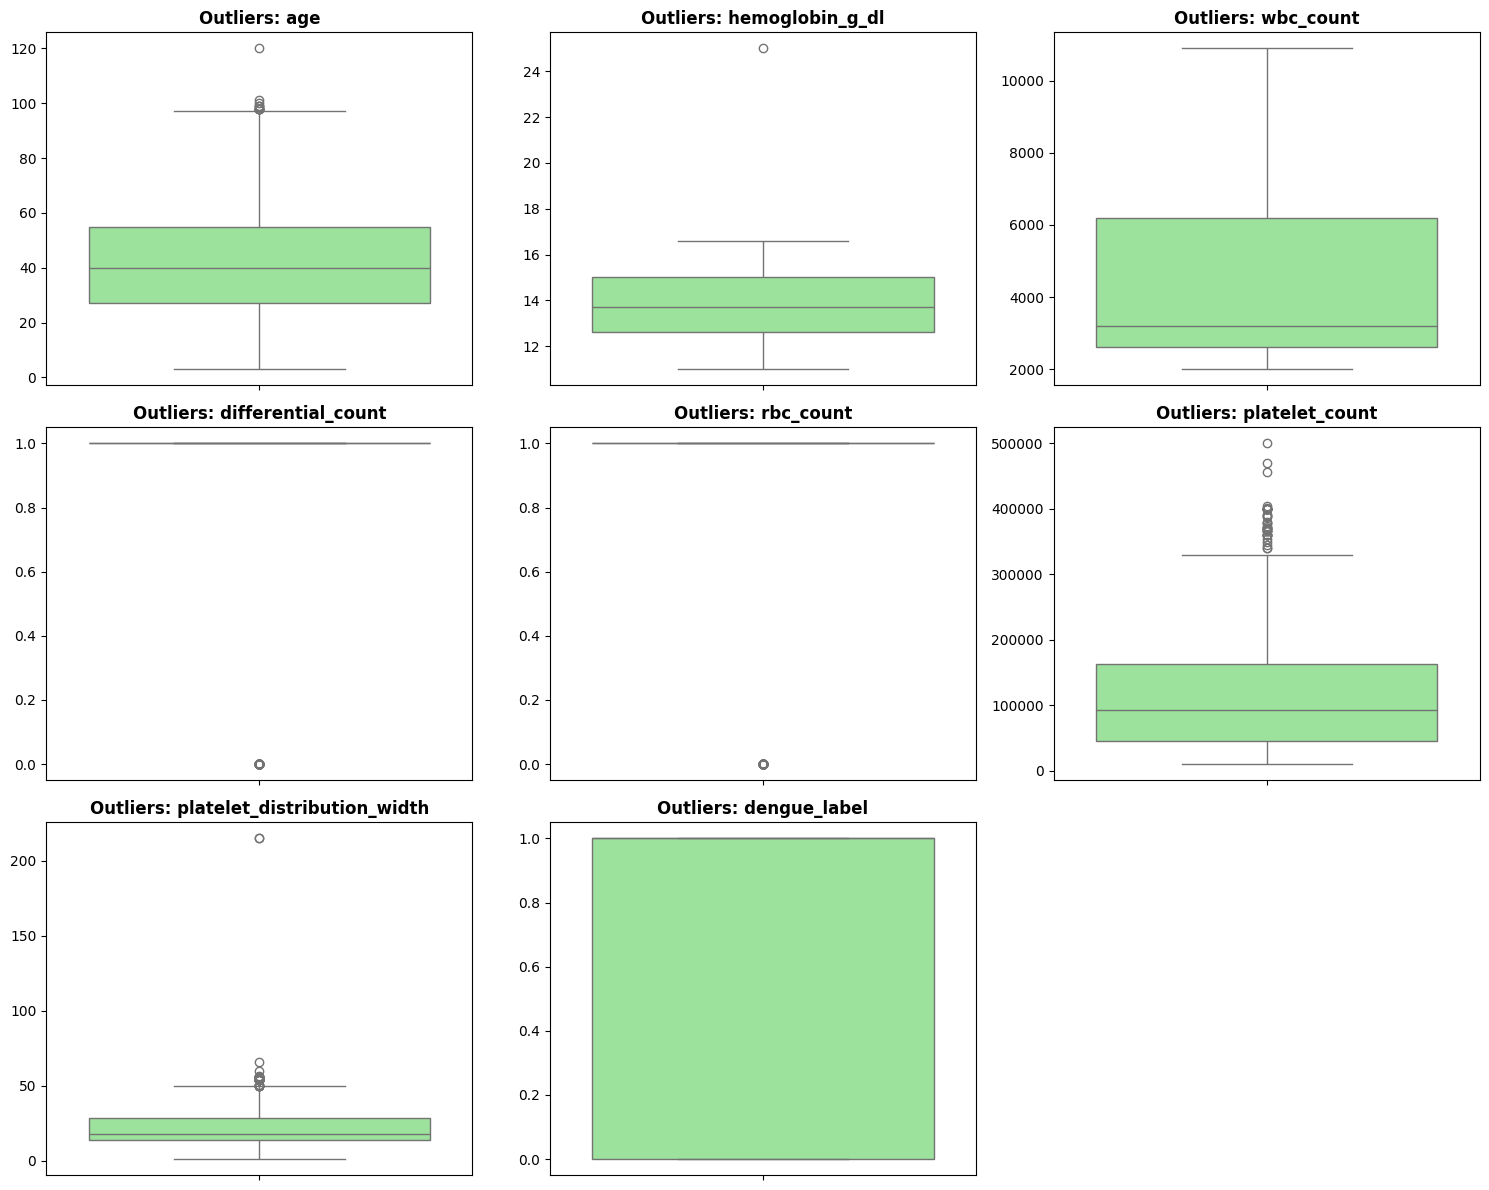

In [7]:
import pandas as pd
import math

df = data
numeric_features = df.select_dtypes(include=['number']).columns
categorical_features = df.select_dtypes(include=['object']).columns

jumlah_fitur = len(numeric_features)

# 2. Atur tata letak grid (misal: 3 kolom per baris)
kolom_grid = 3
baris_grid = math.ceil(jumlah_fitur / kolom_grid)

# 3. Buat kanvas (figure) dan kotak-kotaknya (axes)
# figsize diatur dinamis: lebar 15, tinggi menyesuaikan jumlah baris
fig, axes = plt.subplots(baris_grid, kolom_grid, figsize=(15, 4 * baris_grid))
axes = axes.flatten() # Ratakan array kotak agar mudah diisi pakai loop

# 4. Looping untuk menggambar boxplot Seaborn ke dalam masing-masing kotak
for i, col in enumerate(numeric_features):
    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Outliers: {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('') # Sembunyikan label Y agar UI lebih bersih

# 5. Hapus kotak sisa yang kosong (jika total fitur Anda bukan kelipatan 3)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 6. Rapikan jarak antar kotak dan tampilkan
plt.tight_layout()
plt.show()

In [8]:
def cap_outliers_efficient(df, columns):
    df_capped = df.copy() # Membuat salinan agar data asli tidak rusak
    
    for col in columns:
        # Menentukan batas bawah (persentil 5%) dan atas (persentil 95%)
        lower_bound = df_capped[col].quantile(0.01)
        upper_bound = df_capped[col].quantile(0.99)
        
        # Fungsi clip() akan otomatis membatasi nilai yang kelebihan/kekurangan
        df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)
        
    return df_capped

# Penggunaan:
df = cap_outliers_efficient(df, numeric_features)
df.describe()

,age,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width,dengue_label
count,989.000000,989.000000,965.000000,989.000000,989.000000,973.000000,970.000000,989.000000
mean,42.179980,13.703236,4335.440415,0.939333,0.938322,114479.384378,22.516082,0.651163
std,20.827564,1.440728,2338.117291,0.238840,0.240692,88535.848501,11.846188,0.476843
min,5.000000,11.000000,2000.000000,0.000000,0.000000,12000.000000,10.000000,0.000000
25%,27.000000,12.600000,2600.000000,1.000000,1.000000,46000.000000,14.000000,0.000000
50%,40.000000,13.700000,3200.000000,1.000000,1.000000,93000.000000,17.800000,1.000000
75%,55.000000,15.000000,6200.000000,1.000000,1.000000,162500.000000,28.200000,1.000000
max,98.000000,16.000000,9800.000000,1.000000,1.000000,400000.000000,55.800000,1.000000


In [9]:
# --- Pilih kolom numerik ---
df = data
bin_cols = ["differential_count", "rbc_count"]
num_cols = df.select_dtypes(include="number").columns
num_cols = [col for col in num_cols if col not in bin_cols]

# Isi NaN dari numerikal feature biar bisa di hitung outliersnya
# df[num_cols] = df[num_cols].fillna(df[num_cols].median())


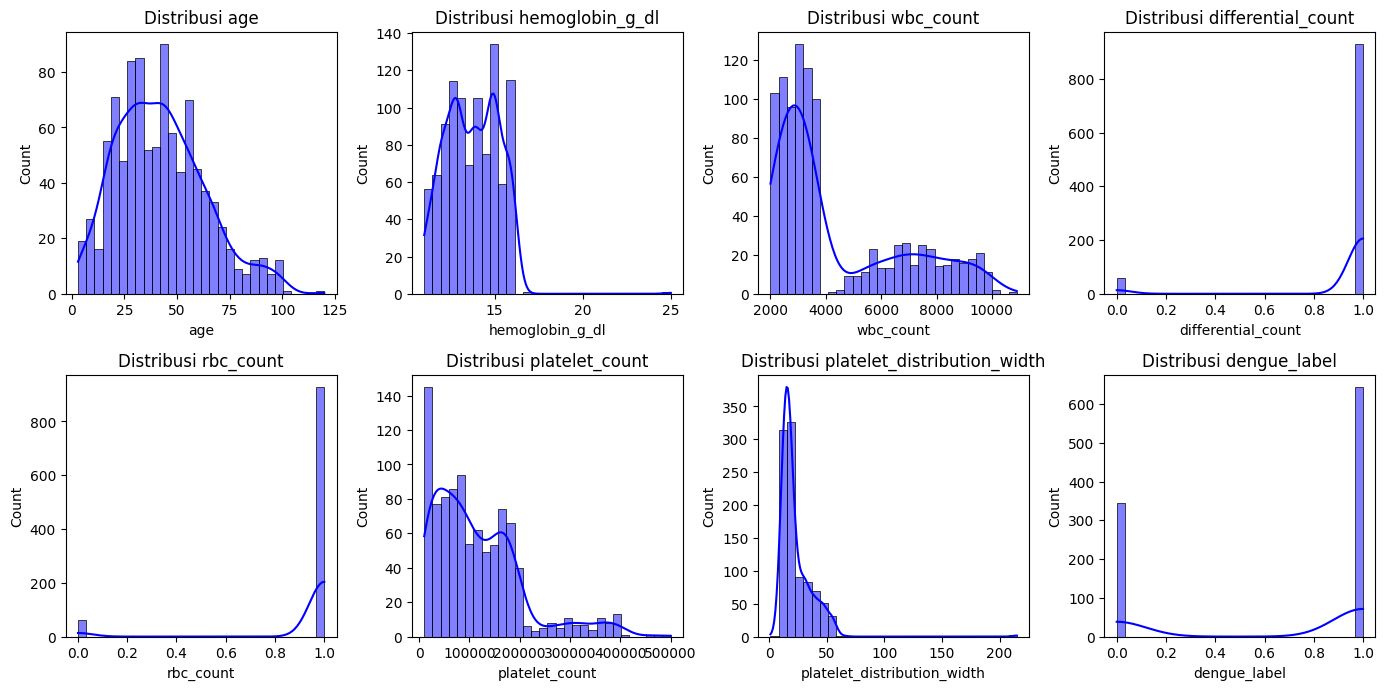

In [10]:
# Melihat distribusi data

# Distribusi fitur numerik
num_features = df.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
for i, column in enumerate(num_features.columns, 1):
    plt.subplot(3, 4, i)
    sns.histplot(data[column], bins=30, kde=True, color='blue')
    plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

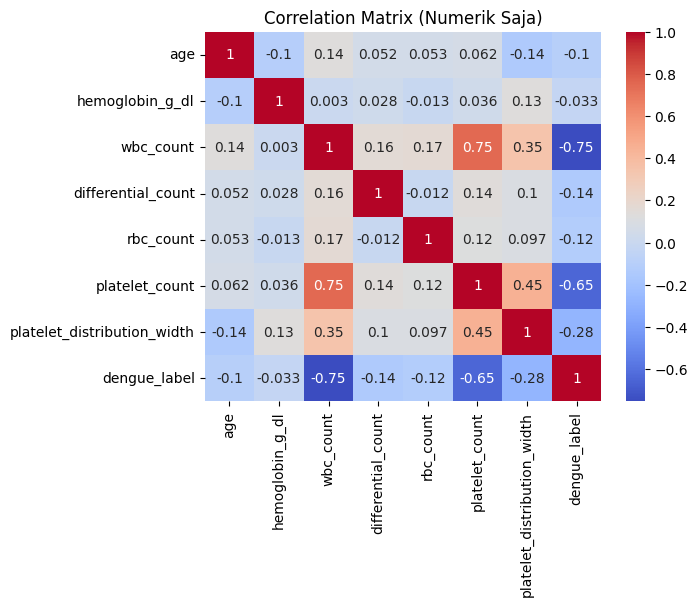

In [11]:
# ✅ 1. Ambil hanya kolom numerik
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix (Numerik Saja)")
plt.show()

In [12]:
df["dengue_label"].value_counts()

dengue_label
1    644
0    345
Name: count, dtype: int64

In [13]:
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols = ['gender']

C:\Users\user\AppData\Local\Temp\ipykernel_23060\1264867195.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from imblearn.pipeline import Pipeline
# # Split Dataset Then Encoding the categorical Dataset
# num_cols
# bin_cols

# Split
X = df.drop(columns='dengue_label')
y = df['dengue_label']
bin_cols = ["differential_count", "rbc_count"]
num_cols = X.select_dtypes(include=['int64', 'Float64']).columns
num_cols = [col for col in num_cols if col not in bin_cols]
cat_cols = X.select_dtypes(include=['object']).columns
# Split into training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Encoding menggunakan Pipeline
# Ada 3 Fitur tadi yaitu num_cols, bin_cols, dan cat_cols
# Kita buat sebuah fungsi sendiri untuk Preprocessingnya menggunakan ColumnTransformer
# kita gunakan standarscaler karena nanti model ML yang digunakan yaitu logistic Regression
ss = StandardScaler()
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# Kita akan membuat 2 Pipeline
num_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', ss)
]
)
preprocessor = ColumnTransformer(transformers=[
    ('num_cols', num_pipeline, num_cols),
    ('cat_cols', ohe, cat_cols)
], remainder='passthrough')

preprocessor.set_output(transform='pandas')


C:\Users\user\AppData\Local\Temp\ipykernel_23060\69486887.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_cols', ...), ('cat_cols', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

In [15]:
X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)
X_test_pre

,num_cols__age,num_cols__hemoglobin_g_dl,num_cols__wbc_count,num_cols__platelet_count,num_cols__platelet_distribution_width,cat_cols__gender_Child,cat_cols__gender_Female,cat_cols__gender_Male,remainder__differential_count,remainder__rbc_count
213,0.569081,-0.472223,1.775436,2.100702,-0.779703,0.0,1.0,0.0,1,1
331,-0.834894,0.737694,-0.739049,-1.015755,-0.200686,0.0,0.0,1.0,1,1
501,2.311947,-1.144399,0.923068,0.604353,-0.654688,0.0,0.0,1.0,1,1
309,0.084952,1.544305,2.286857,2.100702,1.786393,0.0,1.0,0.0,1,1
88,0.762733,0.334388,-0.611194,-0.351961,-0.332281,0.0,1.0,0.0,0,1
...,...,...,...,...,...,...,...,...,...,...
450,0.520669,-0.472223,-0.312865,-0.306958,0.549404,0.0,0.0,1.0,1,1
705,-0.253938,0.804912,-0.866904,-0.431842,-0.213845,0.0,1.0,0.0,1,1
305,0.084952,0.199953,-0.440721,0.075567,-0.013822,0.0,1.0,0.0,1,1
807,-0.399177,0.872129,-0.440721,0.176824,0.194098,0.0,1.0,0.0,1,1


In [32]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

xgb = XGBClassifier(
# scale_pos_weight = 8,
objective='binary:logistic',
eval_metric='logloss',
random_state=42
)

grid_params = {
'model__scale_pos_weight' : [2, 5, 8, 12],
'model__max_depth': [2,3,4,5,6],
'model__learning_rate':np.linspace(0.01,0.1, 1, 5),
'model__n_estimators': [100,200,300],
'model__subsample': [0.6,0.8,1.0],
'model__colsample_bytree': [0.6,0.8,1.0]
}

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    # ('smote', SMOTE(random_state=42)),
    ('model', xgb)
])

grid_search = GridSearchCV(
    pipeline,
    grid_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.6, 0.8, ...], 'model__learning_rate': array([0.01]), 'model__max_depth': [2, 3, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the

In [33]:
best_model = grid_search.best_estimator_
print(grid_search.best_params_)

{'model__colsample_bytree': 0.6, 'model__learning_rate': np.float64(0.01), 'model__max_depth': 2, 'model__n_estimators': 200, 'model__scale_pos_weight': 2, 'model__subsample': 0.6}


In [34]:
y_pred = best_model.predict(X_test)

In [35]:
print(roc_auc_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.5927903871829105
              precision    recall  f1-score   support

           0       0.60      0.43      0.50        91
           1       0.61      0.76      0.68       107

    accuracy                           0.61       198
   macro avg       0.60      0.59      0.59       198
weighted avg       0.60      0.61      0.59       198



In [ ]:
# Coba menggunakan Threshold TUning untuk lebih mengklasifikasi binary
# Di XGBoost, menggunakan probabi
y_prob = best_model.predict_proba(X_test)[:, 1]
thresholds = [0.2, 0.3, 0.4,]

for t in thresholds:
    y_pred = (y_prob > t).astype(int)
    print(t, recall_score(y_test, y_pred))

0.2 0.7663551401869159
0.3 0.7663551401869159
0.4 0.7570093457943925


In [39]:

y_pred = (y_prob > 0.3).astype(int)
print(roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

0.5663448700831878
              precision    recall  f1-score   support

           0       0.61      0.43      0.50        91
           1       0.61      0.77      0.68       107

    accuracy                           0.61       198
   macro avg       0.61      0.60      0.59       198
weighted avg       0.61      0.61      0.60       198

